# Aufgabe 2

Bei Aufgabe 2 war die einzige veränderung zu 1, dass wir jetzt eine RL und keine RC Reihenschaltung mehr haben. Somit sieht der neue Schaltkreis wie folgt aus:
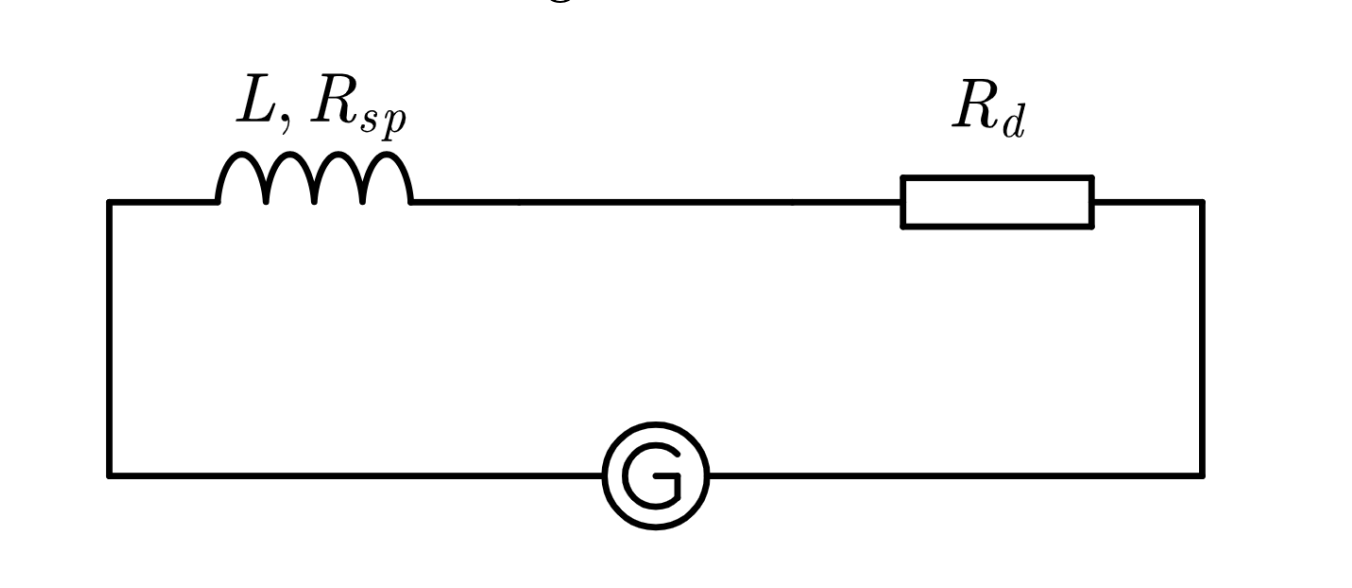
Die Messpunkte sind somit aber gleich geblieben und wir haben diese Messwerte bekommen:
| $\omega$ [Hz] | $U_0 [V] | $U_R$ [V] | $\theta$ [°] |
|----------:|-------:|--------:|------:|
| 100       | 1.237  | 1.238   | 0      |
| 200       | 1.237  | 1.238   | 0.368  |
| 300       | 1.246  | 1.238   | 0.11   |
| 400       | 1.237  | 1.229   | 0.246  |
| 500       | 1.237  | 1.229   | 0.23   |
| 600       | 1.237  | 1.238   | 0.442  |
| 700       | 1.237  | 1.229   | 0.414  |
| 800       | 1.237  | 1.229   | 0.246  |
| 900       | 1.237  | 1.238   | 0.414  |
| 1000      | 1.237  | 1.229   | 0.307  |
| 2000      | 1.237  | 1.229   | 0.768  |
| 3000      | 1.237  | 1.229   | 1.106  |
| 4000      | 1.237  | 1.229   | 1.228  |
| 5000      | 1.237  | 1.238   | 1.871  |
| 6000      | 1.237  | 1.229   | 2.074  |
| 7000      | 1.237  | 1.229   | 2.688  |
| 8000      | 1.237  | 1.229   | 2.305  |
| 9000      | 1.237  | 1.229   | 2.591  |
| 10000     | 1.237  | 1.229   | 3.456  |
| 20000     | 1.237  | 1.229   | 6.719  |
| 30000     | 1.237  | 1.229   | 10.72  |
| 40000     | 1.254  | 1.22    | 14.02  |
| 50000     | 1.263  | 1.202   | 18     |
| 60000     | 1.263  | 1.184   | 21.08  |
| 70000     | 1.272  | 1.167   | 24.86  |
| 80000     | 1.281  | 1.14    | 26.5   |
| 90000     | 1.281  | 1.113   | 30.75  |
| 100000    | 1.272  | 1.078   | 33.12  |


tau = 9.848e-07 s,  L ≈ 0.98 mH,  f_c ≈ 161619 Hz,  Gain ≈ 0.997
Phase: Modell = +arctan, Offset = +0.2°,  RMSE ≈ 0.52°  (Steigung Messung: 1, Modell: 1)


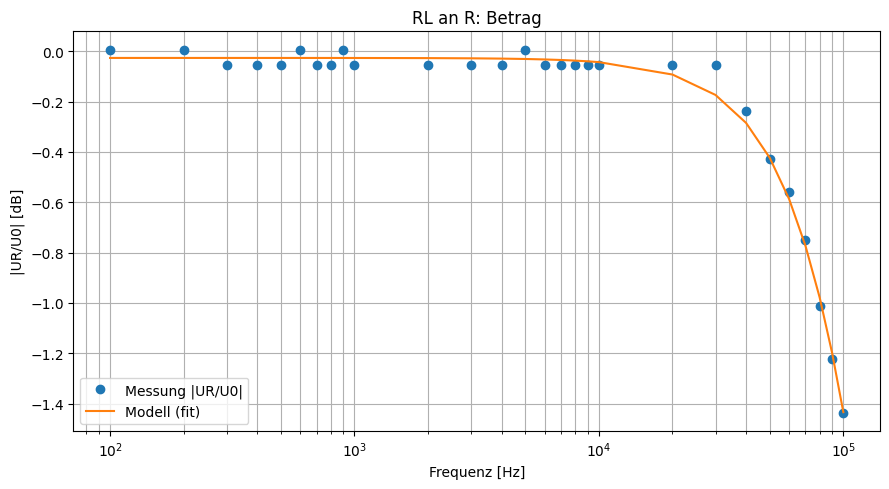

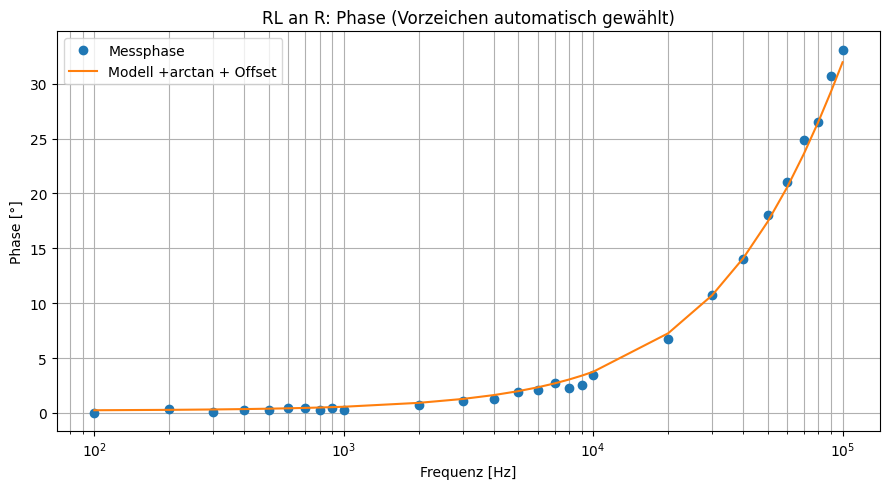

In [5]:
# ==== RL-Serie an R: Betrag-Fit + Phase mit automatischem Vorzeichen ====
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- Parameter ---
R = 1000.0
CSV_PATH = "Messwerte/Aufgabe2.csv"  # ggf. anpassen

# --- Helpers ---
def wrap_pm180(d): return ((d + 180.0) % 360.0) - 180.0
def mag2db(x): return 20*np.log10(np.clip(x, 1e-20, None))

def phase_slope_sign(phi_deg, f_hz):
    # Vorzeichen der Steigung von Phase vs log10(f)
    x = np.log10(f_hz); y = phi_deg
    A = np.vstack([x, np.ones_like(x)]).T
    m, b = np.linalg.lstsq(A, y, rcond=None)[0]
    return np.sign(m) if abs(m) > 1e-6 else 0.0

# --- Daten laden ---
df = pd.read_csv(CSV_PATH)
col_f  = next(c for c in df.columns if "Freq"  in c or "freq"  in c or "Frequ" in c)
col_u0 = next(c for c in df.columns if "U_0"  in c or "U0"   in c)
col_ur = next(c for c in df.columns if "U_R"  in c or "UR"   in c)
col_th = next(c for c in df.columns if "theta" in c or "Theta" in c or "phase" in c or "Phase" in c)

f = df[col_f].to_numpy(float)
U0 = df[col_u0].to_numpy(float)
UR = df[col_ur].to_numpy(float)
phase_meas = wrap_pm180(df[col_th].to_numpy(float))
mag_meas = np.clip(UR/U0, 1e-12, None)
w = 2*np.pi*f

# --- 1) Betrag fitten: tau = L/R ---
taus = np.logspace(-7, -4, 1200)  # 0.1 µs .. 100 µs
best = (None, np.inf, 1.0)
for tau in taus:
    mag_model = 1.0/np.sqrt(1.0 + (w*tau)**2)
    g = np.sum(mag_meas*mag_model)/(np.sum(mag_model**2)+1e-20)  # Gain-Korrektur
    err = float(np.sqrt(np.mean((mag2db(mag_meas)-mag2db(g*mag_model))**2)))
    if err < best[1]: best = (tau, err, g)

tau = best[0]; gain = best[2]
L   = tau*R
fc  = 1.0/(2*np.pi*tau)
print(f"tau = {tau:.3e} s,  L ≈ {L*1e3:.2f} mH,  f_c ≈ {fc:.0f} Hz,  Gain ≈ {gain:.3f}")

# --- 2) Phase ausrichten: wähle das Vorzeichen, dessen Steigung zu deiner Messung passt ---
phi_model_neg = -np.degrees(np.arctan(w*tau))     # ideal für UR relativ zu U0 (fallend)
phi_model_pos = +np.degrees(np.arctan(w*tau))     # falls Gerät U0 relativ zu UR misst (steigend)

sign_meas = phase_slope_sign(phase_meas, f)
sign_neg  = phase_slope_sign(phi_model_neg, f)
sign_pos  = phase_slope_sign(phi_model_pos, f)

# Kandidaten: (Modell, Name)
cands = [(phi_model_neg, "−arctan"), (phi_model_pos, "+arctan")]
# bevorzuge den Kandidaten, dessen Steigungssignal mit der Messung übereinstimmt
cands.sort(key=lambda M: 0 if phase_slope_sign(M[0], f)==sign_meas else 1)

# nun Konstant-Offset per zirkulärem Mittel
def circ_mean_offset(a_deg, b_deg):
    diff = np.deg2rad(a_deg - b_deg)
    ang = np.arctan2(np.mean(np.sin(diff)), np.mean(np.cos(diff)))
    return np.rad2deg(ang)

phi_base, label = cands[0]
phi0 = circ_mean_offset(phase_meas, phi_base)
phi_fit = phi_base + phi0

# Güte
rmse_phase = float(np.sqrt(np.mean(wrap_pm180(phase_meas - phi_fit)**2)))
print(f"Phase: Modell = {label}, Offset = {phi0:+.1f}°,  RMSE ≈ {rmse_phase:.2f}°  "
      f"(Steigung Messung: {int(sign_meas)}, Modell: {int(phase_slope_sign(phi_base,f))})")

# --- Plots ---
# Betrag
plt.figure(figsize=(9,5))
plt.xscale("log")
plt.plot(f, mag2db(mag_meas), marker="o", linestyle="none", label="Messung |UR/U0|")
plt.plot(f, mag2db(gain*(1.0/np.sqrt(1.0 + (w*tau)**2))), label="Modell (fit)")
plt.xlabel("Frequenz [Hz]"); plt.ylabel("|UR/U0| [dB]")
plt.title("RL an R: Betrag")
plt.grid(True, which="both"); plt.legend(); plt.tight_layout(); plt.show()

# Phase
plt.figure(figsize=(9,5))
plt.xscale("log")
plt.plot(f, phase_meas, marker="o", linestyle="none", label="Messphase")
plt.plot(f, phi_fit, label=f"Modell {label} + Offset")
plt.xlabel("Frequenz [Hz]"); plt.ylabel("Phase [°]")
plt.title("RL an R: Phase (Vorzeichen automatisch gewählt)")
plt.grid(True, which="both"); plt.legend(); plt.tight_layout(); plt.show()
